# modkit pileup outputs

##### Modules

In [1]:
import os
import pandas as pd
import numpy as np
import itertools

import upsetplot
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Functions

In [124]:
def load_and_bin(path, bin_size=1000):
    """
    Load modkit CpG bed file and return dataframe with
    median methylation (%) per 1 kb bin.
    """
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        compression="gzip",
        names=pileup_cols,
        usecols=usecols,
    )

    # define fixed 1 kb windows on the genome
    df["bin_start"] = (df["start"] // bin_size) * bin_size
    df["bin_end"]   = df["bin_start"] + bin_size

    # median percent_mod per (chrom, 1 kb bin)
    df_bin = (
        df.groupby(["chrom", "bin_start", "bin_end"], as_index=False)["percent_mod"]
          .median()
          .rename(columns={"percent_mod": "percent_mod"})
    )

    return df_bin

In [105]:
def plot_pair_bins(name_x, name_y, df_x, df_y, chr='All', ax=None):
    """
    Make a pairwise methylation comparison plot into `ax`.
    Returns (fig, ax, hist2d_quadmesh_object).
    """

    # Merge bins
    merged = pd.merge(
        df_x, df_y,
        on=["chrom", "bin_start", "bin_end"],
        suffixes=(f"_{name_x}", f"_{name_y}")
    )
    if chr != 'All':
        merged = merged[merged["chrom"] == chr]

    x = merged[f"percent_mod_{name_x}"].values
    y = merged[f"percent_mod_{name_y}"].values

    # Correlation
    r, _ = stats.pearsonr(x, y)
    n = len(x)

    # If no axis supplied, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    # 2D histogram (h[3] is the QuadMesh object needed for shared colorbar)
    h = ax.hist2d(
        x, y,
        bins=100,
        range=[[0, 100], [0, 100]],
        norm=LogNorm()
    )

    # 1:1 line
    ax.plot([0, 100], [0, 100], ls="--", lw=1, color="red")

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    ax.set_xlabel(f"{name_x} meth/bin (%)", fontsize=label_size)
    ax.set_ylabel(f"{name_y} meth/bin (%)", fontsize=label_size)

    ax.set_title(
        f"1 kb bins, median\n r={r:.3f} (n={n:,})",
        fontsize=title_size
    )

    return fig, ax, h[3]   # <-- return QuadMesh for colorbar

In [125]:
def plot_pair_CpGs(name_x, name_y, df_x, df_y, ax=None):
    """
    Make a pairwise methylation comparison plot.
    If ax is provided, plot into that axis.
    Otherwise create a new figure and axis.
    Returns (fig, ax).
    """

    # Merge bins
    merged = pd.merge(
        df_x, df_y,
        on=["chrom", "start"],
        suffixes=(f"_{name_x}", f"_{name_y}")
    )

    x = merged[f"percent_mod_{name_x}"].values
    y = merged[f"percent_mod_{name_y}"].values

    # Correlation
    r, _ = stats.pearsonr(x, y)
    n = len(x)

    # If no axis supplied, create figure+axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    # Plot 2D histogram
    h = ax.hist2d(
        x, y,
        bins=100,
        range=[[0, 100], [0, 100]],
        norm=LogNorm()
    )

    # Add colorbar only if using a standalone axis
    if ax is None:
        plt.colorbar(h[3], ax=ax, label="CpGs (log count)")
    else:
        fig.colorbar(h[3], ax=ax, label="CpGs (log count)")

    # 1:1 line
    ax.plot([0, 100], [0, 100], ls="--", lw=1, color="red")

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    ax.set_xlabel(f"{name_x} % meth per CpG", fontsize=label_size)
    ax.set_ylabel(f"{name_y} % meth per CpG", fontsize=label_size)

    ax.set_title(
        f"Single CpGs, median; r={r:.3f} (n={n:,})",
        fontsize=title_size
    )

    return fig, ax

##### Fonts & Colors

In [100]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# font size
b = 1
title_size = 18 + b
label_size = 16 + b
tick_size = 12 + b

# colors
colors = ['midnightblue', 'darkolivegreen', 'darkgoldenrod']

##### Inputs

In [67]:
pileup_cols = [
    'chrom',
    'start',
    'end',
    'name',
    'score',
    'strand',
    'start1',
    'end1',
    'color',
    'valid_coverage',
    'percent_mod',
    'count_modified',
    'count_canonical',
    'count_other_mod',
    'count_delete',
    'count_fail',
    'count_diff',
    'count_nocall',
]
usecols = ["chrom", "start", "percent_mod"]

In [82]:
# dirs
DIR1 = "/scratch/eger/projects/MethSmoothEval/tissues/modkit/pileup"
DIR2 = "/scratch/eger/projects/MethSmoothEval/tissues/UXM_deconv/Atlas.U25.l4.hg38"

# pileup paths
standard_pileups = {
    "Bulk_FC_Control_02": DIR1+"/Bulk_FC_Control_02.cpg.bed.gz",
    "colo829bl":          DIR1+"/colo829bl.cpg.bed.gz",
    "hg002_blood":        DIR1+"/hg002_blood.cpg.bed.gz",
}
hp_pileups = {
    "Bulk_FC_Control_02": [DIR1+"/Bulk_FC_Control_02.cpg.hp_1.bed.gz", DIR1+"/Bulk_FC_Control_02.cpg.hp_2.bed.gz"],
    "colo829bl": [DIR1+"/colo829bl.cpg.hp_1.bed.gz", DIR1+"/colo829bl.cpg.hp_2.bed.gz"],
    "hg002_blood": [DIR1+"/hg002_blood.cpg.hp_1.bed.gz", DIR1+"/hg002_blood.cpg.hp_2.bed.gz"],
}

# deconvolution results
uxm1 = os.path.join(DIR2, 'Bulk_FC_Control_02.Atlas.U25.l4.hg38.UMX_deconv.csv')
uxm2 = os.path.join(DIR2, 'Blood.Atlas.U25.l4.hg38.UMX_deconv.csv')

### Binning & combining pileups

In [83]:
BIN_SIZE = 1000  # 1 kb genomic bins

# Load & bin all samples
# binned_dict = {name: load_and_bin(path, bin_size=BIN_SIZE) for name, path in standard_pileups.items()}

hp_binned_dict = {name: [load_and_bin(paths[0], bin_size=BIN_SIZE), 
                         load_and_bin(paths[1], bin_size=BIN_SIZE)] for name, paths in hp_pileups.items()}

### Pairwise sample comparison

#### chr22 bins

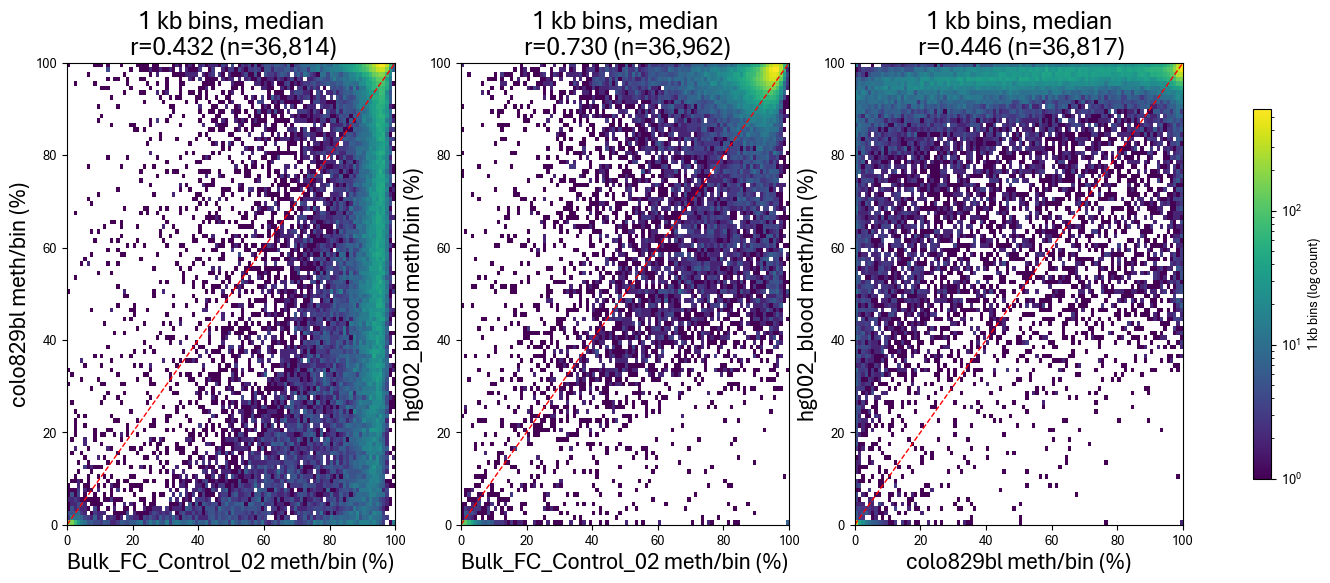

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = list(itertools.combinations(binned_dict.keys(), 2))
quadmeshes = []  # store hist2d objects

for ax, (name_x, name_y) in zip(axes, pairs):
    df_x = binned_dict[name_x]
    df_y = binned_dict[name_y]
    _, _, qm = plot_pair_bins(name_x, name_y, df_x, df_y, ax=ax, chr='chr22')
    quadmeshes.append(qm)

# Use the FIRST (or last) QuadMesh as reference for color scale
cbar = fig.colorbar(
    quadmeshes[0],
    ax=axes,
    label="1 kb bins (log count)",
    location='right',
    shrink=0.8,
)

#plt.subplots_adjust(right=0.08, left=0.05)
plt.show()

#### chr22 CpGs

In [69]:
# single CpGs
chr = 'chr22'
chr_dict = {}
for name, path in standard_pileups.items():
    df = pd.read_csv(
            path,
            sep="\t",
            header=None,
            names=pileup_cols,
            usecols=usecols)
    df = df[df['chrom'] == chr]
    chr_dict[name] = df

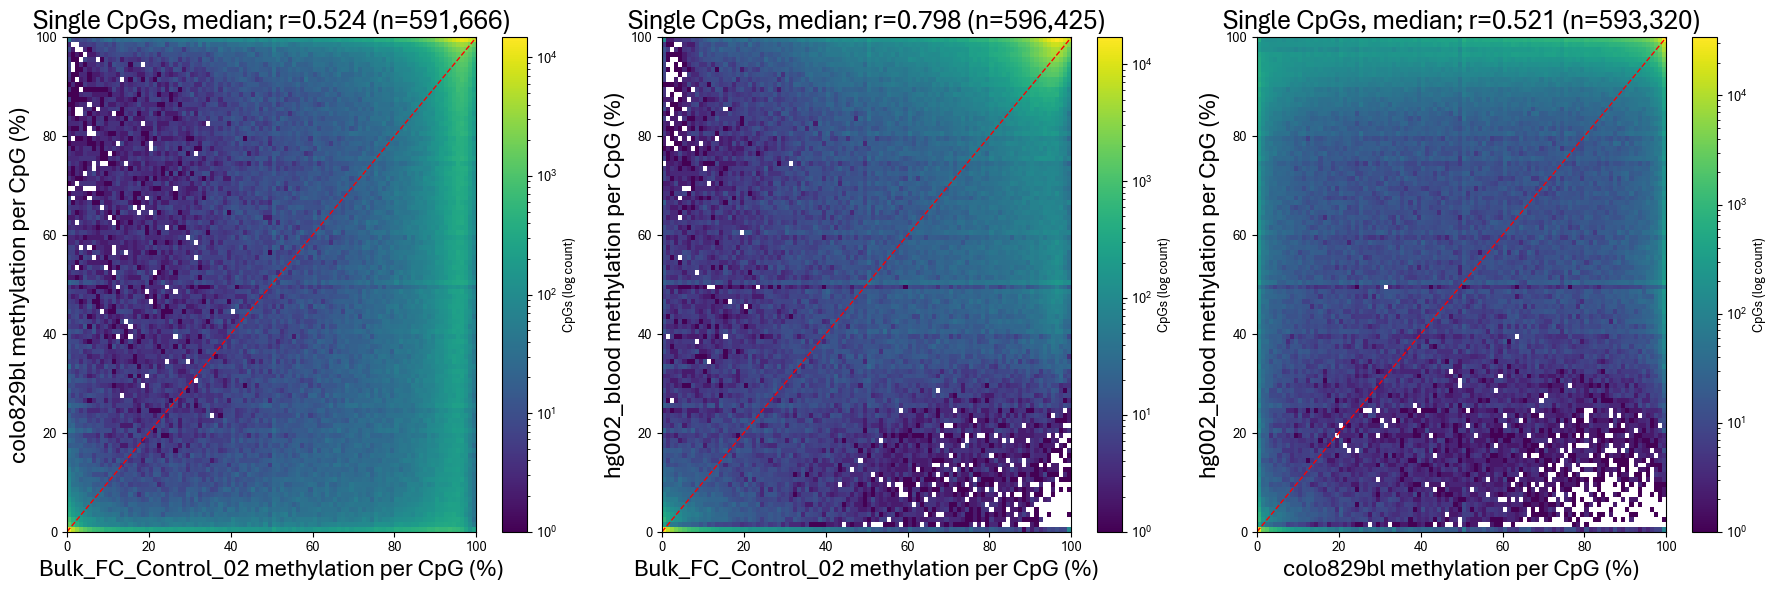

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = list(itertools.combinations(chr_dict.keys(), 2))
for ax, (name_x, name_y) in zip(axes, pairs):
    df_x = chr_dict[name_x]
    df_y = chr_dict[name_y]
    plot_pair_CpGs(name_x, name_y, df_x, df_y, ax=ax)

plt.tight_layout()
plt.show()

#### All chromosomes bins

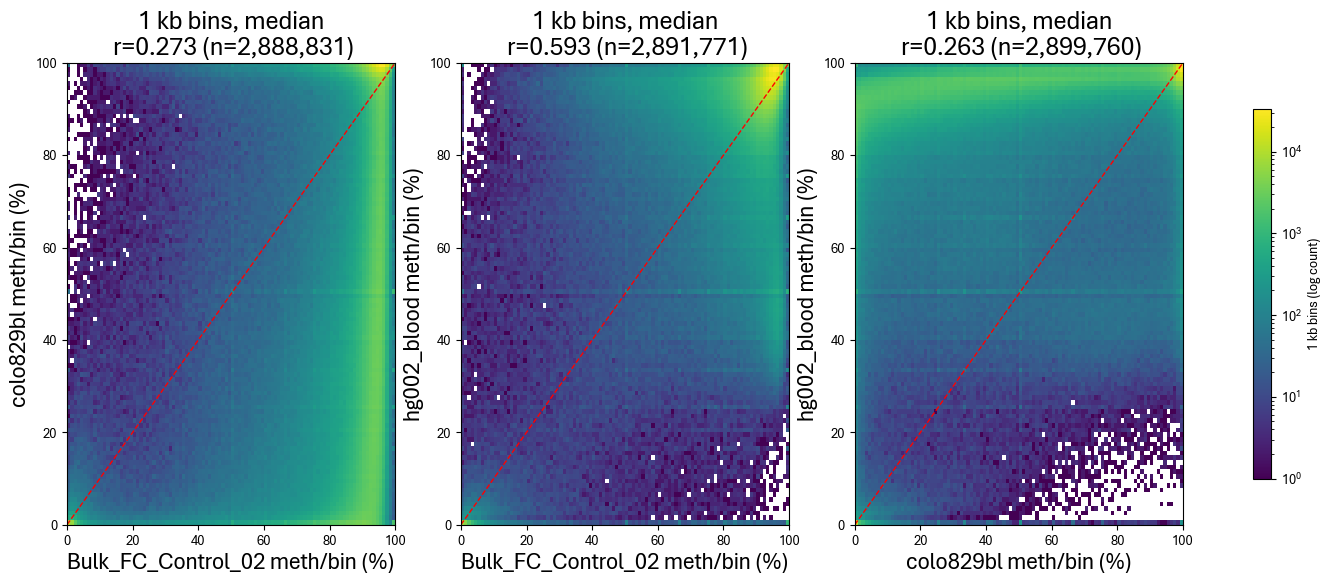

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = list(itertools.combinations(binned_dict.keys(), 2))
quadmeshes = []  # store hist2d objects

for ax, (name_x, name_y) in zip(axes, pairs):
    df_x = binned_dict[name_x]
    df_y = binned_dict[name_y]
    _, _, qm = plot_pair_bins(name_x, name_y, df_x, df_y, ax=ax)
    quadmeshes.append(qm)

# Use the FIRST (or last) QuadMesh as reference for color scale
cbar = fig.colorbar(
    quadmeshes[0],
    ax=axes,
    label="1 kb bins (log count)",
    location='right',
    shrink=0.8,
)
plt.show()

### HP comparison

#### chr22 bins

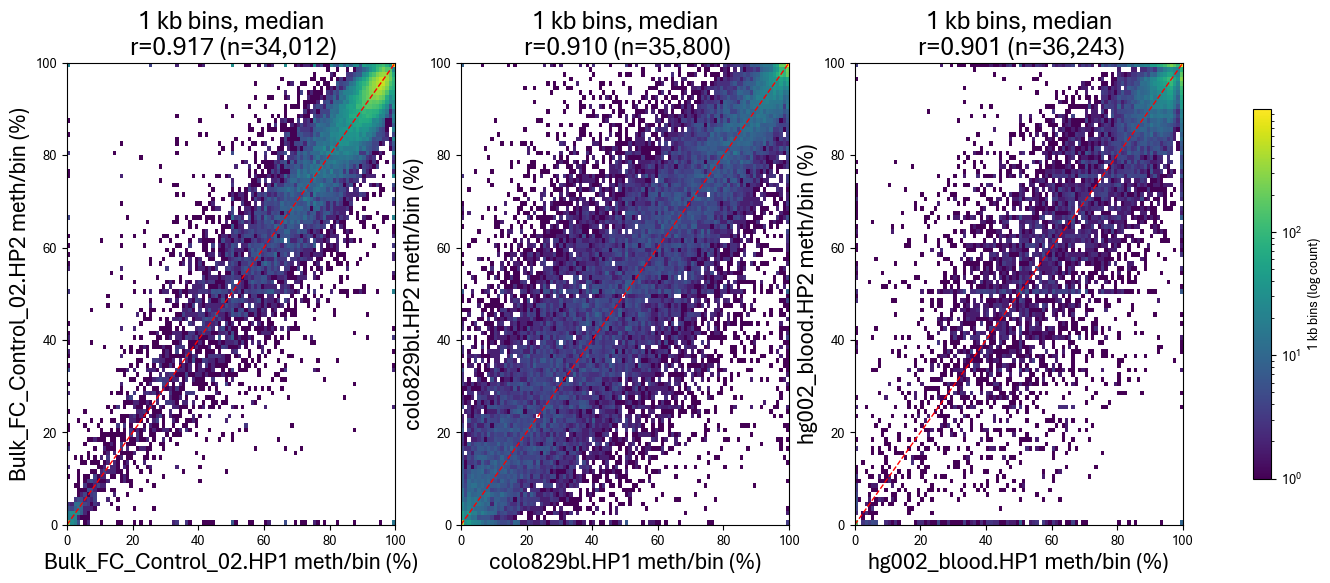

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

quadmeshes = []  # store hist2d objects
for ax, sample in zip(axes, hp_binned_dict.keys()):
    df_x = hp_binned_dict[sample][0]
    df_y = hp_binned_dict[sample][1]
    _, _, qm = plot_pair_bins(sample+'.HP1', sample+'.HP2', df_x, df_y, ax=ax, chr='chr22')
    quadmeshes.append(qm)

# Use the FIRST (or last) QuadMesh as reference for color scale
cbar = fig.colorbar(
    quadmeshes[0],
    ax=axes,
    label="1 kb bins (log count)",
    location='right',
    shrink=0.8,
)

plt.show()

#### chr22 CpGs

In [87]:
# single CpGs
chr = 'chr22'
chr_dict = {}
for name, paths in hp_pileups.items():
    pile_dfs = []
    for path in paths:
        df = pd.read_csv(
                path,
                sep="\t",
                header=None,
                names=pileup_cols,
                usecols=usecols)
        df = df[df['chrom'] == chr]
        pile_dfs.append(df)
    chr_dict[name] = pile_dfs

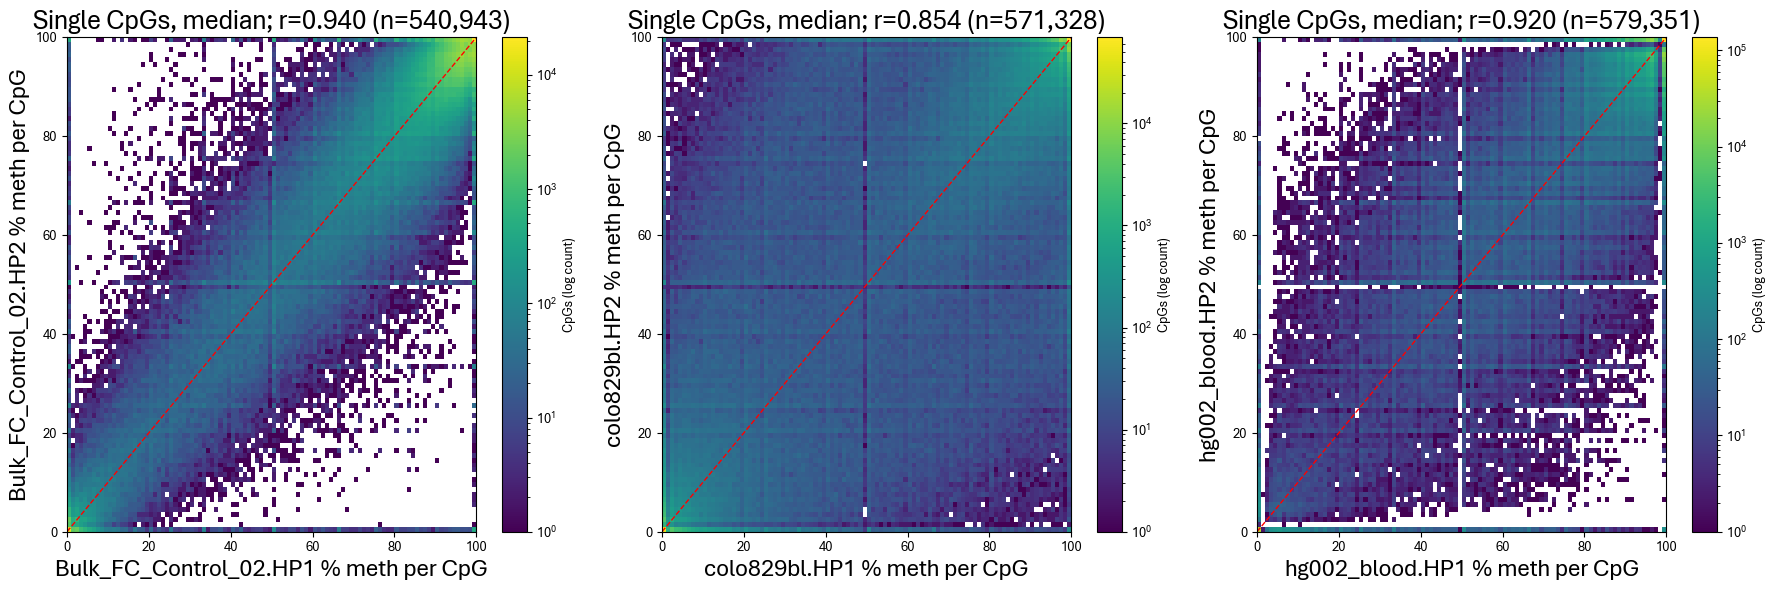

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sample in zip(axes, chr_dict.keys()):
    df_x = chr_dict[sample][0]
    df_y = chr_dict[sample][1]
    plot_pair_CpGs(sample+'.HP1', sample+'.HP2', df_x, df_y, ax=ax)

plt.tight_layout()
plt.show()

#### All chromosomes bins

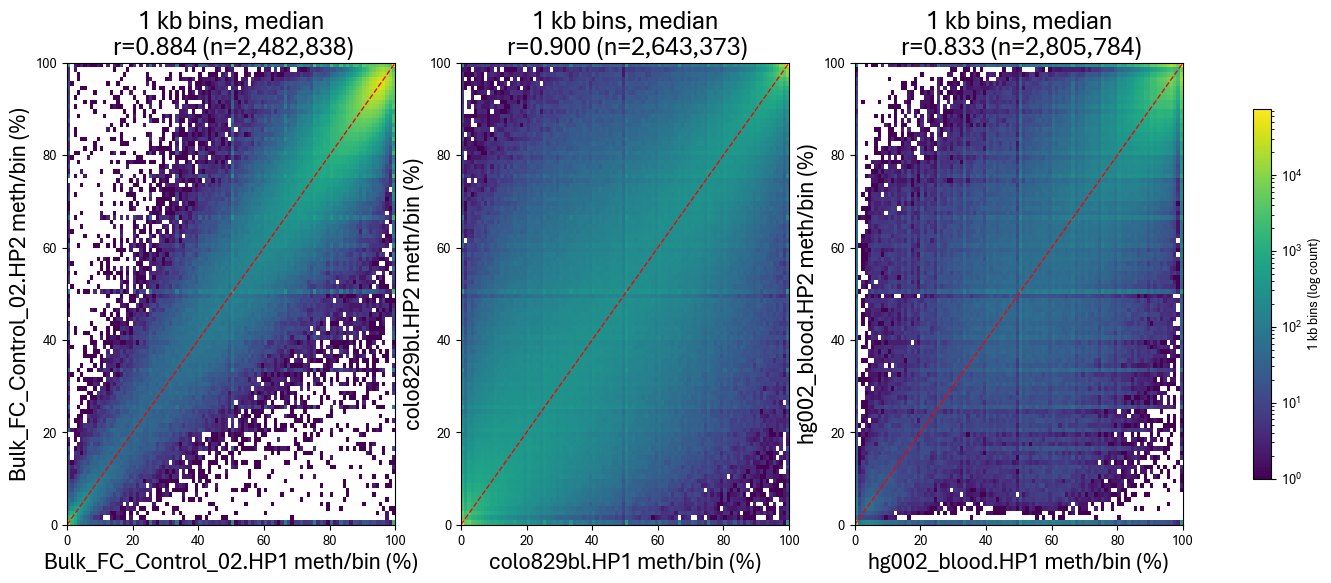

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

quadmeshes = []  # store hist2d objects
for ax, sample in zip(axes, hp_binned_dict.keys()):
    df_x = hp_binned_dict[sample][0]
    df_y = hp_binned_dict[sample][1]
    _, _, qm = plot_pair_bins(sample+'.HP1', sample+'.HP2', df_x, df_y, ax=ax)
    quadmeshes.append(qm)

# Use the FIRST (or last) QuadMesh as reference for color scale
cbar = fig.colorbar(
    quadmeshes[0],
    ax=axes,
    label="1 kb bins (log count)",
    location='right',
    shrink=0.8,
)

plt.show()